# 4. XGBoost Baseline

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import joblib

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


## 4.1 Load Train, Validation, and Test Splits

In [2]:
# Resolve the project root so the notebook works across different systems
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

split_dir = PROJECT_DIR / "data" / "processed" / "tabular_splits"

X_train = pd.read_csv(split_dir / "X_train.csv")
X_val = pd.read_csv(split_dir / "X_val.csv")
X_test = pd.read_csv(split_dir / "X_test.csv")

y_train = pd.read_csv(split_dir / "y_train.csv").squeeze("columns")
y_val = pd.read_csv(split_dir / "y_val.csv").squeeze("columns")
y_test = pd.read_csv(split_dir / "y_test.csv").squeeze("columns")

print("Data loaded successfully.\n")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Data loaded successfully.

X_train: (27938, 165)
X_val: (9313, 165)
X_test: (9313, 165)
y_train: (27938,)
y_val: (9313,)
y_test: (9313,)


In [3]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class count (licit):", negative_count)
print("Positive class count (illicit):", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Negative class count (licit): 25211
Positive class count (illicit): 2727
scale_pos_weight: 9.245


The `scale_pos_weight` parameter is used to account for class imbalance during training. Since illicit transactions form the minority class, this weighting helps reduce the tendency of the model to favor the majority licit class.

## 4.2 Helper Functions for Evaluation

In [4]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return metrics

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted Licit", "Predicted Illicit"],
                yticklabels=["Actual Licit", "Actual Illicit"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

def plot_roc_curve(y_true, y_proba, title):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_pr_curve(y_true, y_proba, title):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label="PR Curve")
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4.3 Train the XGBoost Model

In [5]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [6]:
xgb_val_pred = xgb_model.predict(X_val)
xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]

xgb_val_metrics = evaluate_model("XGBoost - Validation", y_val, xgb_val_pred, xgb_val_proba)
pd.DataFrame([xgb_val_metrics])

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,XGBoost - Validation,0.990766,0.963923,0.940594,0.952116,0.996191,0.984133


XGBoost - Validation Classification Report:

              precision    recall  f1-score   support

           0     0.9936    0.9962    0.9949      8404
           1     0.9639    0.9406    0.9521       909

    accuracy                         0.9908      9313
   macro avg     0.9788    0.9684    0.9735      9313
weighted avg     0.9907    0.9908    0.9907      9313



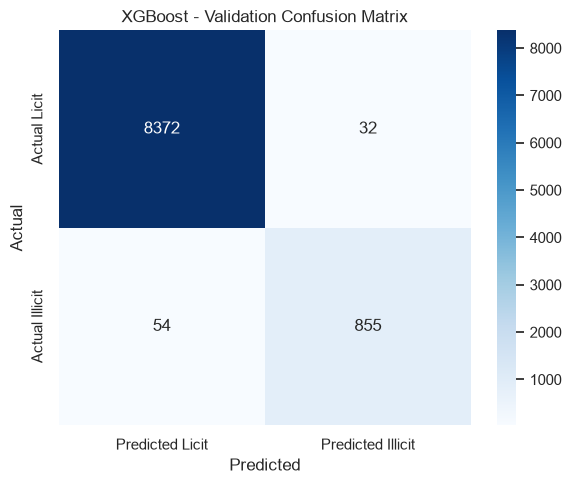

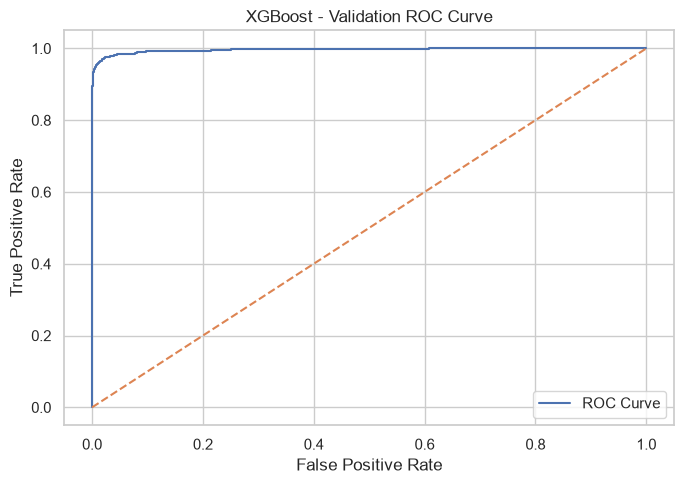

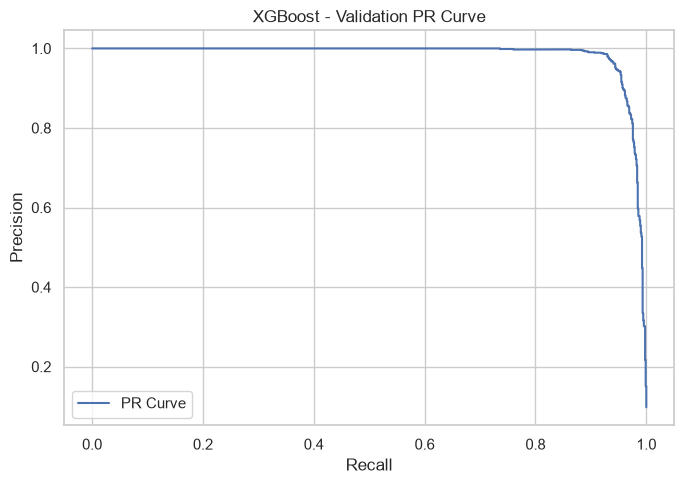

In [7]:
print("XGBoost - Validation Classification Report:\n")
print(classification_report(y_val, xgb_val_pred, digits=4))

plot_confusion_matrix(y_val, xgb_val_pred, "XGBoost - Validation Confusion Matrix")
plot_roc_curve(y_val, xgb_val_proba, "XGBoost - Validation ROC Curve")
plot_pr_curve(y_val, xgb_val_proba, "XGBoost - Validation PR Curve")

XGBoost - Validation Classification Report:

              precision    recall  f1-score   support

           0     0.9936    0.9962    0.9949      8404
           1     0.9639    0.9406    0.9521       909

    accuracy                         0.9908      9313
   macro avg     0.9788    0.9684    0.9735      9313
weighted avg     0.9907    0.9908    0.9907      9313



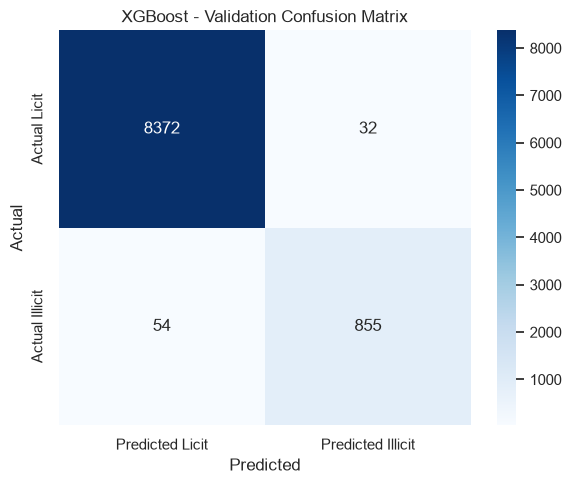

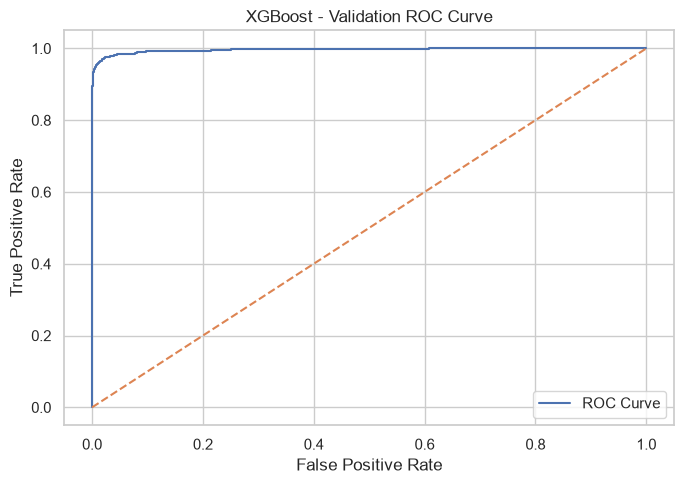

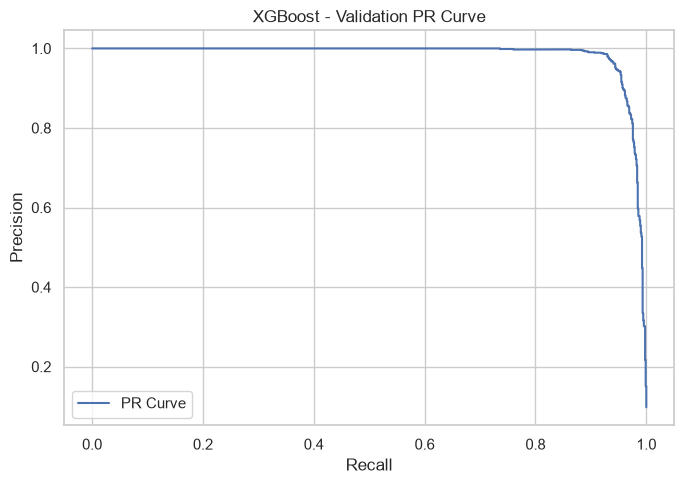

In [8]:
print("XGBoost - Validation Classification Report:\n")
print(classification_report(y_val, xgb_val_pred, digits=4))

plot_confusion_matrix(y_val, xgb_val_pred, "XGBoost - Validation Confusion Matrix")
plot_roc_curve(y_val, xgb_val_proba, "XGBoost - Validation ROC Curve")
plot_pr_curve(y_val, xgb_val_proba, "XGBoost - Validation PR Curve")

The validation results provide the first indication of whether XGBoost improves on the earlier baseline models. Since the dataset is imbalanced, attention should be paid to illicit-class precision, recall, F1-score, and PR-AUC.

## 4.4 Feature Importance Analysis

In [9]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(feature_importance_df.head(15))

,feature,importance
89,91,0.097659
58,60,0.062988
64,66,0.052368
52,54,0.048798
4,6,0.045518
13,15,0.032535
45,47,0.028794
152,154,0.026788
162,164,0.025613
48,50,0.023274


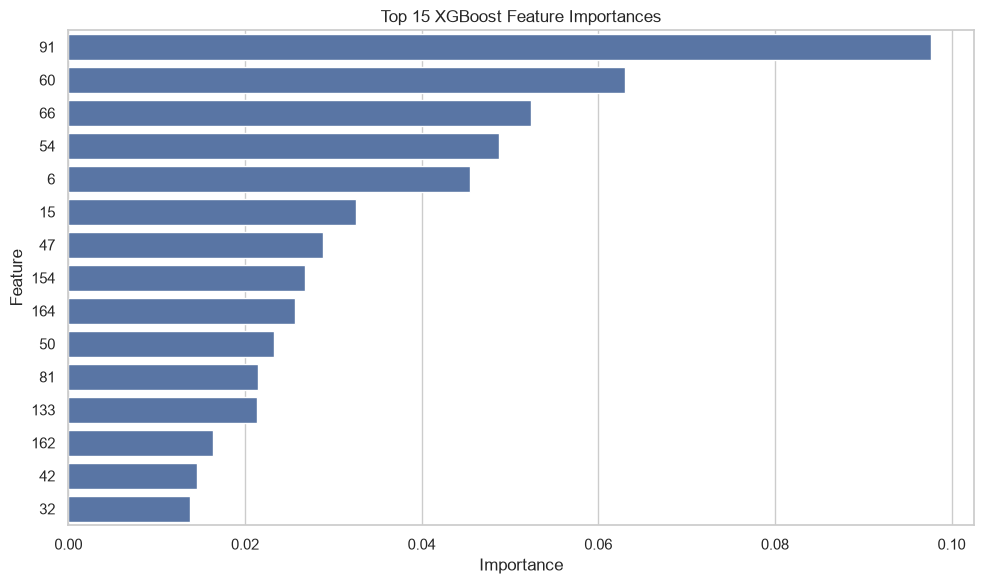

In [10]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Although the Elliptic features are anonymized, the feature importance ranking still gives useful evidence about which variables are driving predictive performance. This can later be compared with SHAP analysis or with the behavior of graph-based models.

## 4.5 Final Evaluation on the Test Set

In [11]:
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_test_metrics = evaluate_model("XGBoost - Test", y_test, xgb_test_pred, xgb_test_proba)
pd.DataFrame([xgb_test_metrics])

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,XGBoost - Test,0.991839,0.974914,0.940594,0.957447,0.997405,0.985981


XGBoost - Test Classification Report:

              precision    recall  f1-score   support

           0     0.9936    0.9974    0.9955      8404
           1     0.9749    0.9406    0.9574       909

    accuracy                         0.9918      9313
   macro avg     0.9843    0.9690    0.9765      9313
weighted avg     0.9918    0.9918    0.9918      9313



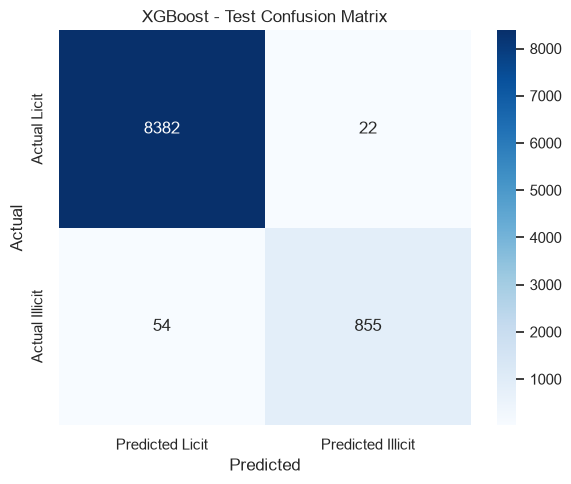

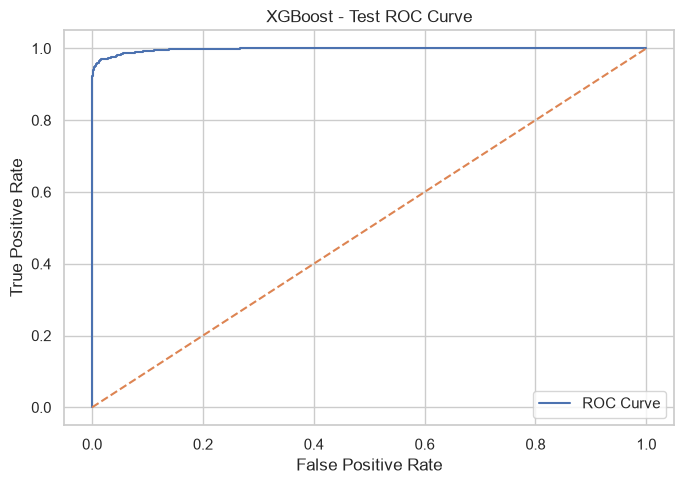

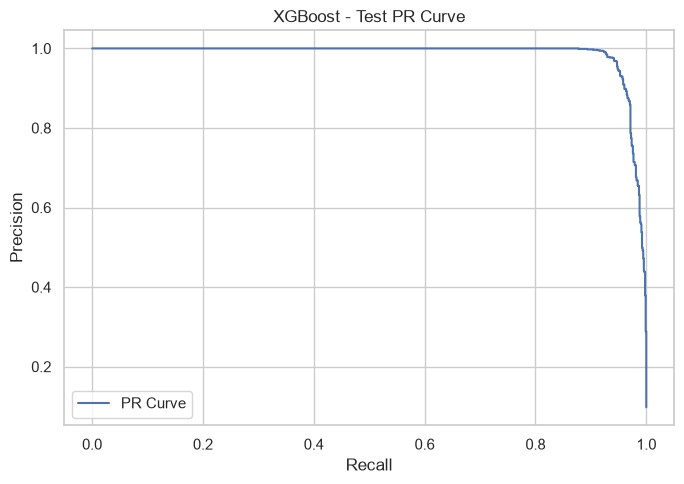

In [12]:
print("XGBoost - Test Classification Report:\n")
print(classification_report(y_test, xgb_test_pred, digits=4))

plot_confusion_matrix(y_test, xgb_test_pred, "XGBoost - Test Confusion Matrix")
plot_roc_curve(y_test, xgb_test_proba, "XGBoost - Test ROC Curve")
plot_pr_curve(y_test, xgb_test_proba, "XGBoost - Test PR Curve")

## 4.6 Compare XGBoost Against Previous Baselines

In [13]:
results_dir = PROJECT_DIR / "results"
baseline_test_results = pd.read_csv(results_dir / "baseline_test_results.csv")

display(baseline_test_results)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression - Test,0.877483,0.439520,0.927393,0.596392,0.964486,0.747469
1,Random Forest - Test,0.987544,0.952109,0.918592,0.935050,0.995770,0.977396


In [14]:
xgb_test_results_df = pd.DataFrame([xgb_test_metrics])

all_test_results_df = pd.concat(
    [baseline_test_results, xgb_test_results_df],
    ignore_index=True
)

display(all_test_results_df.sort_values(by="f1_score", ascending=False))

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
2,XGBoost - Test,0.991839,0.974914,0.940594,0.957447,0.997405,0.985981
1,Random Forest - Test,0.987544,0.952109,0.918592,0.935050,0.995770,0.977396
0,Logistic Regression - Test,0.877483,0.439520,0.927393,0.596392,0.964486,0.747469


This combined comparison shows how much improvement XGBoost provides over the earlier tabular baselines. XGBoost outperforms both Logistic Regression and Random Forest, it will serve as the strongest tabular benchmark for later comparison with GCN and GAT.

## 4.7 Save Model and Results

In [15]:
models_dir = PROJECT_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_model, models_dir / "xgboost_model.pkl")
feature_importance_df.to_csv(results_dir / "xgboost_feature_importance.csv", index=False)
xgb_test_results_df.to_csv(results_dir / "xgboost_test_results.csv", index=False)

all_test_results_df.to_csv(results_dir / "all_tabular_test_results.csv", index=False)

print("XGBoost model and results saved successfully.")

XGBoost model and results saved successfully.


In [16]:
xgb_summary = {
    "xgboost_validation": xgb_val_metrics,
    "xgboost_test": xgb_test_metrics
}

with open(results_dir / "xgboost_metrics_summary.json", "w") as f:
    json.dump(xgb_summary, f, indent=4)

print("XGBoost JSON summary saved.")

XGBoost JSON summary saved.
